# Data Preprocessing and Feature Selection
Here, data will be cleaned and feature selection will be used to improve model performance. Finally, data will also be split for final app validation

In [1]:
import pandas as pd
import df2img
from sklearn import set_config
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.feature_selection import VarianceThreshold

In [2]:
set_config(transform_output='pandas')

In [3]:
# Load dataset
data = pd.read_csv('../data/cybersecurity_intrusion_data.csv', keep_default_na=False)
data

,session_id,network_packet_size,protocol_type,login_attempts,session_duration,encryption_used,ip_reputation_score,failed_logins,browser_type,unusual_time_access,attack_detected
0,SID_00001,599,TCP,4,492.983263,DES,0.606818,1,Edge,0,1
1,SID_00002,472,TCP,3,1557.996461,DES,0.301569,0,Firefox,0,0
2,SID_00003,629,TCP,3,75.044262,DES,0.739164,2,Chrome,0,1
3,SID_00004,804,UDP,4,601.248835,DES,0.123267,0,Unknown,0,1
4,SID_00005,453,TCP,5,532.540888,AES,0.054874,1,Firefox,0,0
...,...,...,...,...,...,...,...,...,...,...,...
9532,SID_09533,194,ICMP,3,226.049889,AES,0.517737,3,Chrome,0,1
9533,SID_09534,380,TCP,3,182.848475,None,0.408485,0,Chrome,0,0
9534,SID_09535,664,TCP,5,35.170248,AES,0.359200,1,Firefox,0,0
9535,SID_09536,406,TCP,4,86.664703,AES,0.537417,1,Chrome,1,0


In [4]:
# check for duplicates
total_dupes = data.duplicated().sum()
total_dupes

0

In [5]:
# Drop session ID since it is a categorical variable with high cardinality with no obvious relation to attacks.
data_noid = data.drop('session_id', axis = 1) # axis = 1 for columns
data_noid 

,network_packet_size,protocol_type,login_attempts,session_duration,encryption_used,ip_reputation_score,failed_logins,browser_type,unusual_time_access,attack_detected
0,599,TCP,4,492.983263,DES,0.606818,1,Edge,0,1
1,472,TCP,3,1557.996461,DES,0.301569,0,Firefox,0,0
2,629,TCP,3,75.044262,DES,0.739164,2,Chrome,0,1
3,804,UDP,4,601.248835,DES,0.123267,0,Unknown,0,1
4,453,TCP,5,532.540888,AES,0.054874,1,Firefox,0,0
...,...,...,...,...,...,...,...,...,...,...
9532,194,ICMP,3,226.049889,AES,0.517737,3,Chrome,0,1
9533,380,TCP,3,182.848475,None,0.408485,0,Chrome,0,0
9534,664,TCP,5,35.170248,AES,0.359200,1,Firefox,0,0
9535,406,TCP,4,86.664703,AES,0.537417,1,Chrome,1,0


In [6]:
# Setup Pipeline for numerical data
num_scaler = Pipeline([
    ('num', StandardScaler())
])


In [7]:
# Setup Pipeline for Categorical Data
cat_scaler = Pipeline([
    ('cat', OneHotEncoder(sparse_output=False))
])

In [8]:
# Setup Feature selection to eliminate low variance features
var_select = Pipeline([
    ('var', VarianceThreshold(0.1))
])

In [9]:
# Combine into one estimator via ColumnTransformer
preprocess = ColumnTransformer([
    ('num', num_scaler, ['network_packet_size','login_attempts', 'session_duration', 'ip_reputation_score', 'failed_logins']),
    ('cat', cat_scaler, ['encryption_used', 'browser_type', 'protocol_type' ])
], remainder='passthrough', )

Unusual Time Access and Attack Detected are already onehot encoded

In [10]:
data_scaled = preprocess.fit_transform(data_noid)
data_scaled

,num__network_packet_size,num__login_attempts,num__session_duration,num__ip_reputation_score,num__failed_logins,cat__encryption_used_AES,cat__encryption_used_DES,cat__encryption_used_None,cat__browser_type_Chrome,cat__browser_type_Edge,cat__browser_type_Firefox,cat__browser_type_Safari,cat__browser_type_Unknown,cat__protocol_type_ICMP,cat__protocol_type_TCP,cat__protocol_type_UDP,remainder__unusual_time_access,remainder__attack_detected
0,0.496899,-0.016346,-0.381125,1.554930,-0.500779,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0,1
1,-0.143322,-0.525794,0.972960,-0.168029,-1.467959,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0,0
2,0.648132,-0.525794,-0.912503,2.301950,0.466400,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0,1
3,1.530327,-0.016346,-0.243473,-1.174443,-1.467959,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0,1
4,-0.239103,0.493102,-0.330830,-1.560484,-0.500779,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9532,-1.544751,-0.525794,-0.720511,1.052117,1.433580,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0,1
9533,-0.607104,-0.525794,-0.775438,0.435452,-1.467959,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0,0
9534,0.824571,0.493102,-0.963200,0.157266,-0.500779,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0,0
9535,-0.476035,-0.016346,-0.897729,1.163198,-0.500779,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1,0


In [11]:
data_selected = var_select.fit_transform(data_scaled)
data_selected

,num__network_packet_size,num__login_attempts,num__session_duration,num__ip_reputation_score,num__failed_logins,cat__encryption_used_AES,cat__encryption_used_DES,cat__encryption_used_None,cat__browser_type_Chrome,cat__browser_type_Edge,cat__browser_type_Firefox,cat__protocol_type_TCP,cat__protocol_type_UDP,remainder__unusual_time_access,remainder__attack_detected
0,0.496899,-0.016346,-0.381125,1.554930,-0.500779,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0,1
1,-0.143322,-0.525794,0.972960,-0.168029,-1.467959,0.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0,0,0
2,0.648132,-0.525794,-0.912503,2.301950,0.466400,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0,1
3,1.530327,-0.016346,-0.243473,-1.174443,-1.467959,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0,1
4,-0.239103,0.493102,-0.330830,-1.560484,-0.500779,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9532,-1.544751,-0.525794,-0.720511,1.052117,1.433580,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0,1
9533,-0.607104,-0.525794,-0.775438,0.435452,-1.467959,0.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0,0,0
9534,0.824571,0.493102,-0.963200,0.157266,-0.500779,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0,0
9535,-0.476035,-0.016346,-0.897729,1.163198,-0.500779,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1,0


It can be seen that Safari and Unknown browser were dropped due to rarity which translates to low variance. The same also happened to the ICMP Protocol

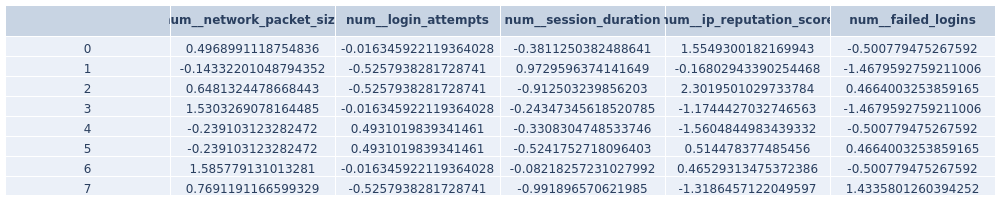

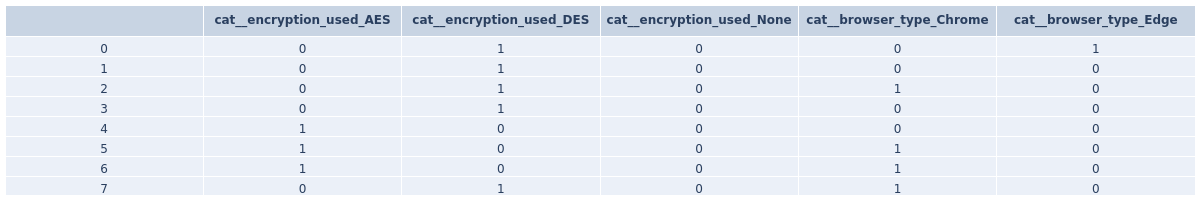

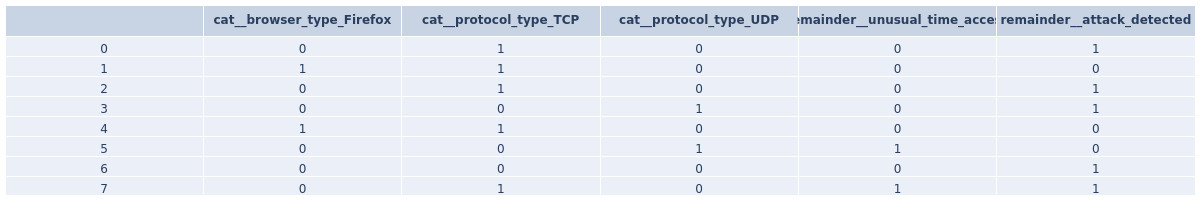

In [12]:
data_1 = data_selected.iloc[:, :5]
data_2 = data_selected.iloc[:, 5:10]
data_3 = data_selected.iloc[:, 10:15]
fig_1 = df2img.plot_dataframe(data_1, fig_size=(1000, 200))
fig_2 = df2img.plot_dataframe(data_2, fig_size=(1200, 200))
fig_3 = df2img.plot_dataframe(data_3, fig_size=(1200, 200))
df2img.save_dataframe(fig_1, filename='../images/scaled_1.png')
df2img.save_dataframe(fig_2, filename='../images/scaled_2.png')
df2img.save_dataframe(fig_3, filename='../images/scaled_3.png')


In [13]:
# Export data for training in separate notebook
data_selected.to_csv('../data/train.csv', index=False)
